# Sobreeducación femenina: ¿trampa educativa sin retorno laboral?

Este análisis examina si las mujeres presentan tasas de sobreeducación más altas que los hombres —es decir, si están empleadas en trabajos que requieren menos educación de la que poseen— y si ese fenómeno varía según el sector económico y el país. Una brecha persistente apuntaría a que la educación no se traduce en mejores empleos para las mujeres de la misma manera que para los hombres.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

DATA_PATH = '/Users/anapreciado/Desktop/github_repos/dataccion-agent/extraction/data/EMP_STAT_SEX_SKL_ECO_NB_A-remodelado-2026-04-05.csv'
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Desajuste values:", df['Desajuste'].unique().tolist())
df.head()

Shape: (807, 7)
Desajuste values: ['Total', 'Poco educado', 'Emparejado', 'Sobre educado', 'No clasificado en otra parte']


,Área de referencia,Fuente,Desajuste,Actividad económica,Año,Mujeres,Hombres
0,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Total,2024,5927.0,7408.4
1,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Agricultura,2024,19.2,61.5
2,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Manufacturas,2024,449.0,961.9
3,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Construcción,2024,52.0,1083.8
4,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Explotación de minas y canteras; Suministro de...,2024,35.9,175.4


In [11]:
# --- Build overeducation rates ---
# Rate = workers with Desajuste='Sobre educado' / workers with Desajuste='Total'
# Compute separately for each (country, activity) pair

total = df[df['Desajuste'] == 'Total'][['Área de referencia', 'Actividad económica', 'Mujeres', 'Hombres']].copy()
sobre = df[df['Desajuste'] == 'Sobre educado'][['Área de referencia', 'Actividad económica', 'Mujeres', 'Hombres']].copy()
poco = df[df['Desajuste'] == 'Poco educado'][['Área de referencia', 'Actividad económica', 'Mujeres', 'Hombres']].copy()
matched = df[df['Desajuste'] == 'Emparejado'][['Área de referencia', 'Actividad económica', 'Mujeres', 'Hombres']].copy()

rates = total.merge(sobre, on=['Área de referencia', 'Actividad económica'],
                    suffixes=('_total', '_sobre'))
rates = rates.merge(poco, on=['Área de referencia', 'Actividad económica'])
rates = rates.merge(matched, on=['Área de referencia', 'Actividad económica'],
                    suffixes=('_poco', '_matched'))

rates['tasa_sobre_mujeres'] = rates['Mujeres_sobre'] / rates['Mujeres_total'] * 100
rates['tasa_sobre_hombres'] = rates['Hombres_sobre'] / rates['Hombres_total'] * 100
rates['brecha_sobre']       = rates['tasa_sobre_mujeres'] - rates['tasa_sobre_hombres']  # + = women more overeducated
rates['tasa_poco_mujeres']  = rates['Mujeres_poco']    / rates['Mujeres_total'] * 100
rates['tasa_poco_hombres']  = rates['Hombres_poco']    / rates['Hombres_total'] * 100

# Country-level totals (Actividad económica == 'Total')
country_rates = rates[rates['Actividad económica'] == 'Total'].copy()
country_rates = country_rates.sort_values('tasa_sobre_mujeres', ascending=False)

# Sector-level (exclude the aggregate 'Total' row)
sector_rates = rates[rates['Actividad económica'] != 'Total'].copy()

countries = rates['Área de referencia'].unique()
COLOR_F = '#E07B8A'
COLOR_M = '#4A7BB5'
COLOR_GAP = '#8B5CF6'

print(f"{len(countries)} países, {sector_rates['Actividad económica'].nunique()} sectores")
country_rates[['Área de referencia', 'tasa_sobre_mujeres', 'tasa_sobre_hombres', 'brecha_sobre']].round(1)

22 países, 7 sectores


,Área de referencia,tasa_sobre_mujeres,tasa_sobre_hombres,brecha_sobre
97,Guyana,36.3,26.2,10.1
156,Uruguay,30.6,27.8,2.8
23,Bolivia (Estado Plurinacional de),27.9,30.3,-2.4
46,Chile,27.5,27.8,-0.3
15,Belice,26.9,23.1,3.8
61,Costa Rica,26.0,31.0,-5.0
54,Colombia,25.7,21.0,4.7
39,Barbados,24.3,24.8,-0.5
141,El Salvador,24.1,30.4,-6.2
90,Guatemala,23.8,27.7,-3.9


### 1. Tasa de sobreeducación por país: mujeres vs. hombres

¿En qué países las mujeres están más sobreeducadas que los hombres?

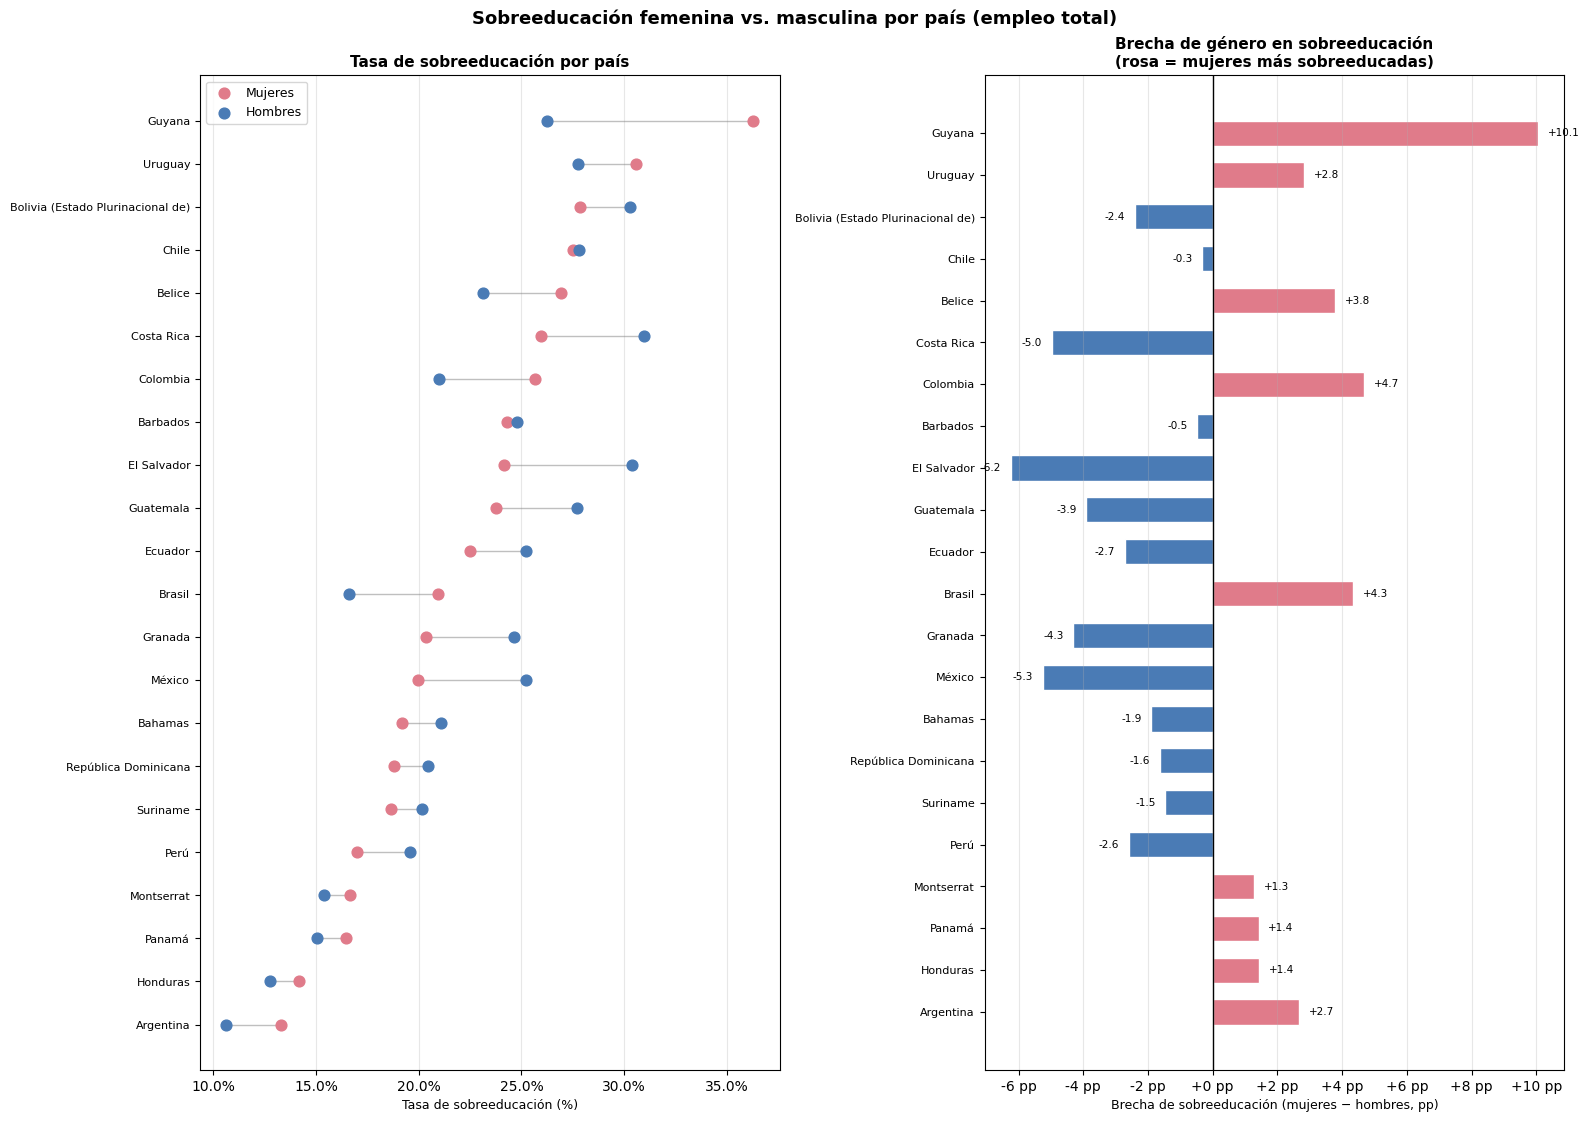

In [12]:
cr = country_rates.sort_values('tasa_sobre_mujeres')
y = np.arange(len(cr))
gap = cr['brecha_sobre']

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(cr) * 0.45 + 1.5)))

# --- Left: grouped dot-plot ---
ax = axes[0]
ax.scatter(cr['tasa_sobre_mujeres'], y, color=COLOR_F, zorder=5, s=60, label='Mujeres')
ax.scatter(cr['tasa_sobre_hombres'], y, color=COLOR_M, zorder=5, s=60, label='Hombres')
# Connector line
for i, (f, m) in enumerate(zip(cr['tasa_sobre_mujeres'], cr['tasa_sobre_hombres'])):
    ax.plot([f, m], [i, i], color='gray', linewidth=1, alpha=0.5)

ax.set_yticks(y)
ax.set_yticklabels(cr['Área de referencia'], fontsize=8)
ax.set_xlabel('Tasa de sobreeducación (%)', fontsize=9)
ax.set_title('Tasa de sobreeducación por país', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# --- Right: gender gap (women − men) ---
ax2 = axes[1]
colors_gap = [COLOR_F if v > 0 else COLOR_M for v in gap]
ax2.barh(y, gap, color=colors_gap, height=0.6, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_yticks(y)
ax2.set_yticklabels(cr['Área de referencia'], fontsize=8)
ax2.set_xlabel('Brecha de sobreeducación (mujeres − hombres, pp)', fontsize=9)
ax2.set_title('Brecha de género en sobreeducación\n(rosa = mujeres más sobreeducadas)', fontsize=11, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f pp'))

# Annotate
for bar, val in zip(ax2.patches, gap):
    xpos = val + (0.3 if val >= 0 else -0.3)
    ha = 'left' if val >= 0 else 'right'
    ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}', va='center', ha=ha, fontsize=7.5)
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Sobreeducación femenina vs. masculina por país (empleo total)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('overeducation_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Mapa de calor: tasa de sobreeducación femenina por país y sector

¿En qué sectores y países se concentra la sobreeducación de las mujeres?

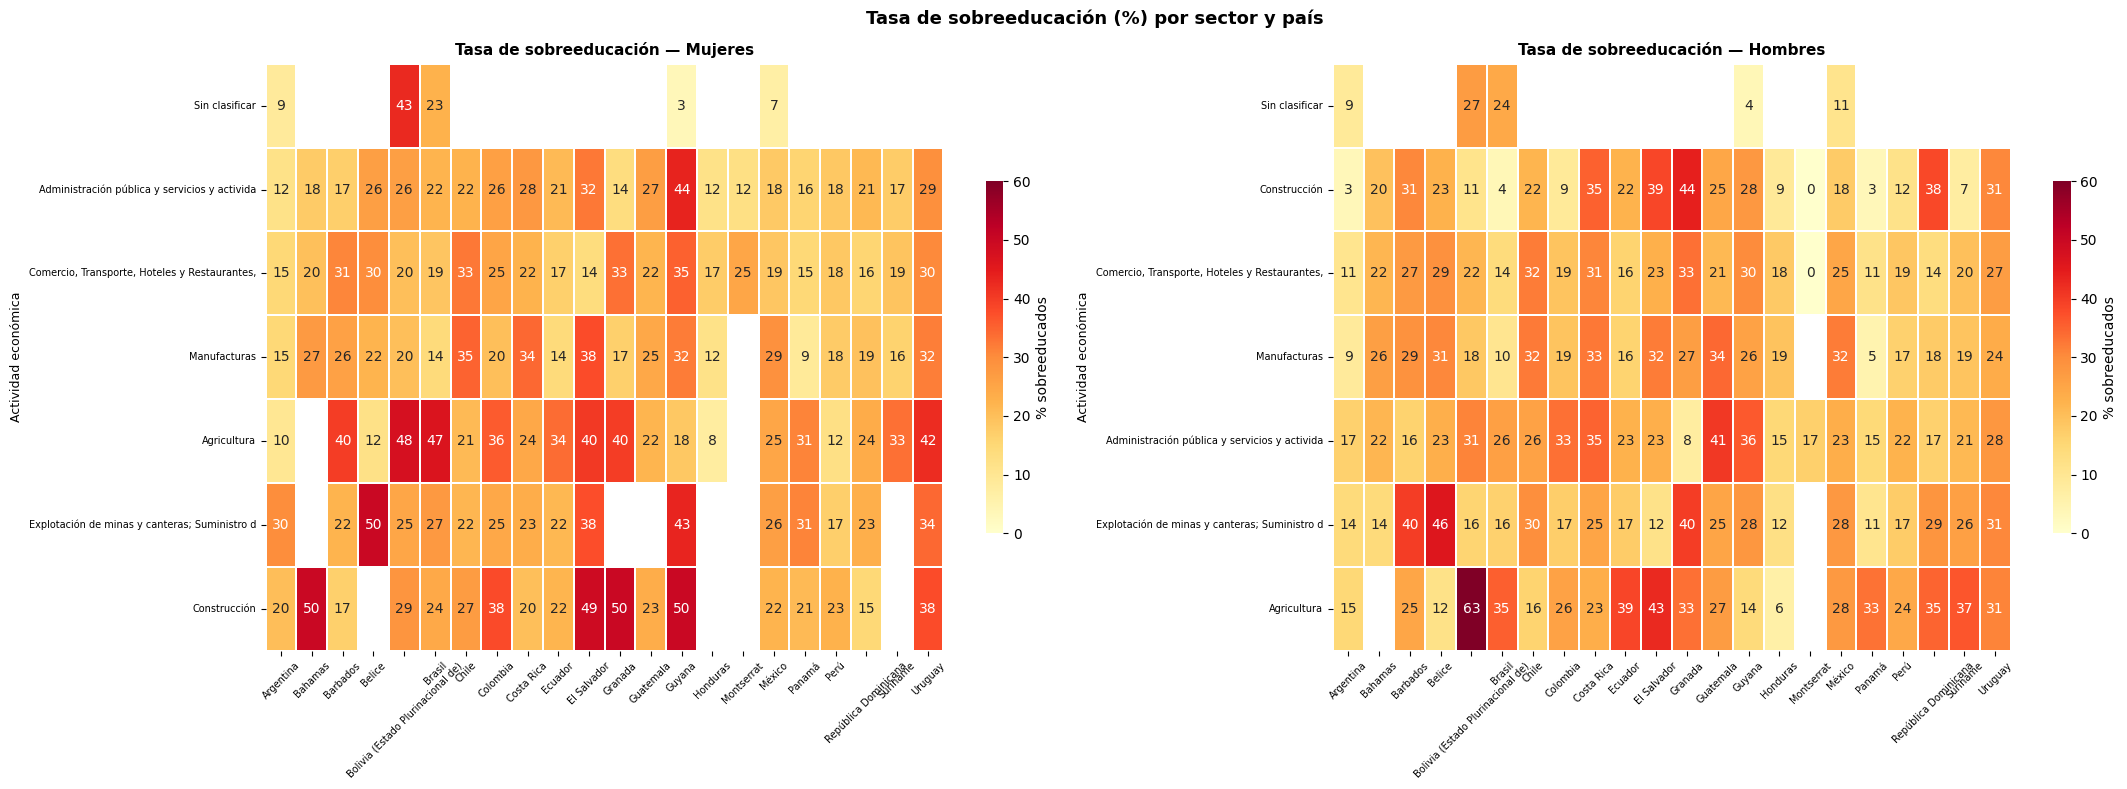

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, col, title in [
    (axes[0], 'tasa_sobre_mujeres', 'Mujeres'),
    (axes[1], 'tasa_sobre_hombres', 'Hombres'),
]:
    pivot = sector_rates.pivot_table(
        index='Actividad económica', columns='Área de referencia',
        values=col, aggfunc='mean'
    )
    # Shorten row labels
    pivot.index = [s[:45] for s in pivot.index]
    # Sort rows by mean rate
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    sns.heatmap(
        pivot, annot=True, fmt='.0f',
        cmap='YlOrRd', vmin=0, vmax=60,
        linewidths=0.3, linecolor='white',
        cbar_kws={'label': '% sobreeducados', 'shrink': 0.6},
        ax=ax
    )
    ax.set_title(f'Tasa de sobreeducación — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Actividad económica', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Tasa de sobreeducación (%) por sector y país', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('overeducation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Brecha de género en sobreeducación por sector (promedio regional)

Diferencia en puntos porcentuales entre la tasa de sobreeducación femenina y masculina. Valores positivos (rosa) indican que las mujeres están más sobreeducadas en ese sector.

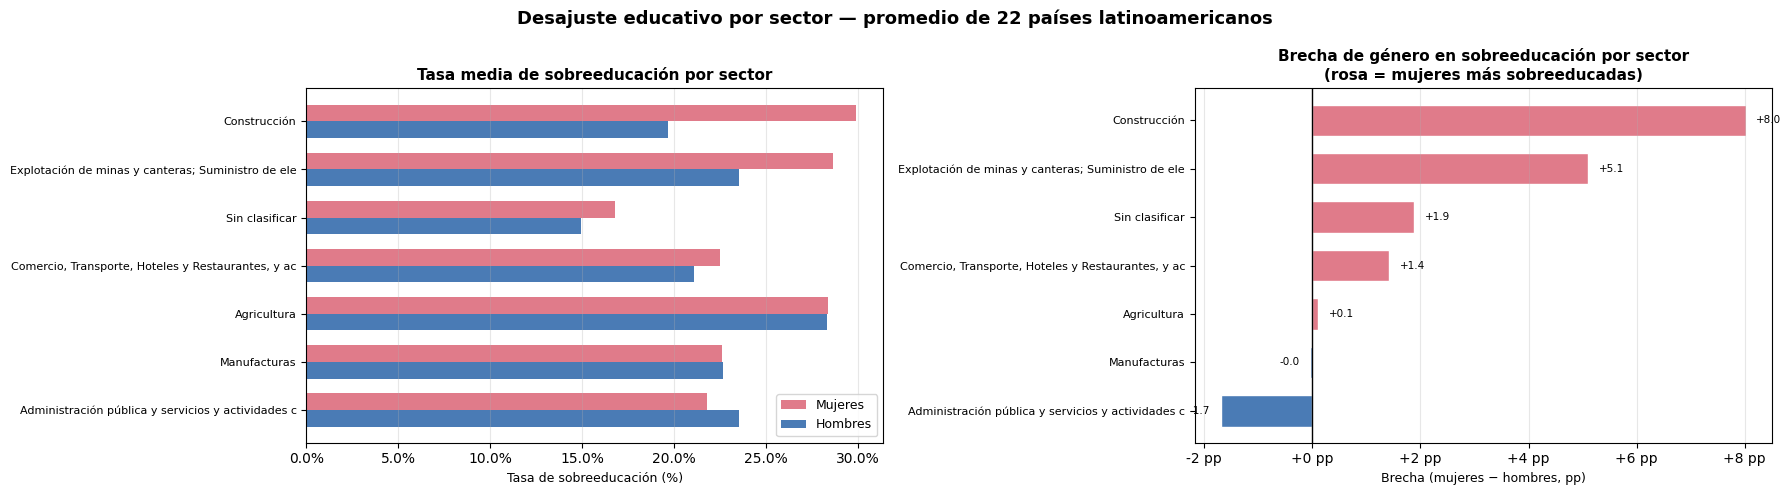

In [14]:
sector_avg = (
    sector_rates
    .groupby('Actividad económica')[['tasa_sobre_mujeres', 'tasa_sobre_hombres', 'brecha_sobre']]
    .mean()
    .reset_index()
    .sort_values('brecha_sobre')
)
sector_avg['Sector_corto'] = sector_avg['Actividad económica'].str.slice(0, 50)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(sector_avg) * 0.5 + 1.5)))

# --- Left: side-by-side rates ---
ax = axes[0]
y = np.arange(len(sector_avg))
bar_h = 0.35
ax.barh(y + bar_h/2, sector_avg['tasa_sobre_mujeres'], bar_h, color=COLOR_F, label='Mujeres')
ax.barh(y - bar_h/2, sector_avg['tasa_sobre_hombres'], bar_h, color=COLOR_M, label='Hombres')
ax.set_yticks(y)
ax.set_yticklabels(sector_avg['Sector_corto'], fontsize=8)
ax.set_xlabel('Tasa de sobreeducación (%)', fontsize=9)
ax.set_title('Tasa media de sobreeducación por sector', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# --- Right: gap ---
ax2 = axes[1]
colors_gap = [COLOR_F if v > 0 else COLOR_M for v in sector_avg['brecha_sobre']]
ax2.barh(y, sector_avg['brecha_sobre'], color=colors_gap, height=0.65, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_yticks(y)
ax2.set_yticklabels(sector_avg['Sector_corto'], fontsize=8)
ax2.set_xlabel('Brecha (mujeres − hombres, pp)', fontsize=9)
ax2.set_title('Brecha de género en sobreeducación por sector\n(rosa = mujeres más sobreeducadas)',
              fontsize=11, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f pp'))
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(ax2.patches, sector_avg['brecha_sobre']):
    xpos = val + (0.2 if val >= 0 else -0.2)
    ha = 'left' if val >= 0 else 'right'
    ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}', va='center', ha=ha, fontsize=7.5)

fig.suptitle('Desajuste educativo por sector — promedio de 22 países latinoamericanos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('overeducation_gap_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. La trampa educativa: sobreeducación vs. participación femenina por sector

Si las mujeres están más sobreeducadas precisamente en los sectores donde son mayoría, eso sugiere que la segregación sectorial *y* la sobreeducación son dos caras de la misma trampa: las mujeres se concentran en ciertos sectores pero aun así acumulan más educación de la que esos empleos demandan.

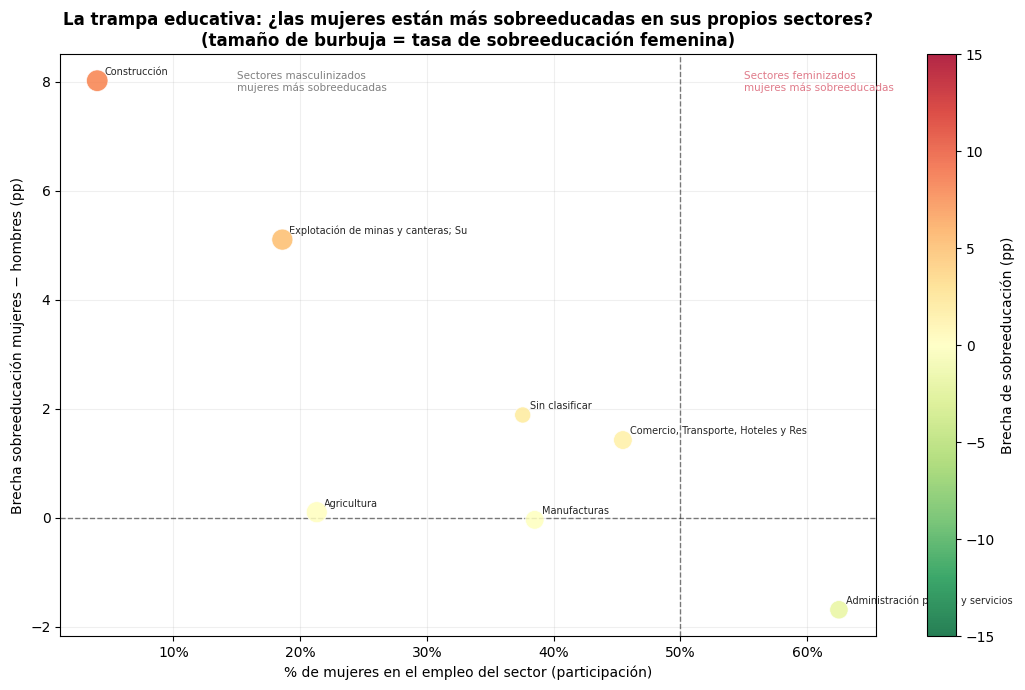

In [15]:
# Compute female employment share per sector (from the 'Total' desajuste slice)
total_sector = df[(df['Desajuste'] == 'Total') & (df['Actividad económica'] != 'Total')].copy()
total_sector['pct_mujeres_empleo'] = (
    total_sector['Mujeres'] / (total_sector['Mujeres'] + total_sector['Hombres']) * 100
)

empleo_share = (
    total_sector.groupby('Actividad económica')['pct_mujeres_empleo']
    .mean()
    .reset_index()
    .rename(columns={'pct_mujeres_empleo': 'participacion_femenina'})
)

scatter_data = sector_avg.merge(empleo_share, on='Actividad económica')
scatter_data['Sector_corto'] = scatter_data['Actividad económica'].str.slice(0, 35)

fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    scatter_data['participacion_femenina'],
    scatter_data['brecha_sobre'],
    s=scatter_data['tasa_sobre_mujeres'] * 8,  # bubble size = magnitude of female overeducation
    c=scatter_data['brecha_sobre'],
    cmap='RdYlGn_r',
    vmin=-15, vmax=15,
    edgecolors='white', linewidths=0.5, alpha=0.85, zorder=5
)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(15, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 8,
        'Sectores masculinizados\nmujeres más sobreeducadas', fontsize=7.5, color='gray', ha='left')
ax.text(55, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 8,
        'Sectores feminizados\nmujeres más sobreeducadas', fontsize=7.5, color=COLOR_F, ha='left')

# Label each bubble
for _, row in scatter_data.iterrows():
    ax.annotate(row['Sector_corto'],
                (row['participacion_femenina'], row['brecha_sobre']),
                fontsize=7, xytext=(5, 4), textcoords='offset points', alpha=0.85)

plt.colorbar(sc, ax=ax, label='Brecha de sobreeducación (pp)')
ax.set_xlabel('% de mujeres en el empleo del sector (participación)', fontsize=10)
ax.set_ylabel('Brecha sobreeducación mujeres − hombres (pp)', fontsize=10)
ax.set_title('La trampa educativa: ¿las mujeres están más sobreeducadas en sus propios sectores?\n'
             '(tamaño de burbuja = tasa de sobreeducación femenina)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('overeducation_trap_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Perfil completo de desajuste: sobre-, bien- y sub-educación por género

¿La sobreeducación femenina coexiste con menor subeducación? Eso indicaría que las mujeres ingresan a empleos por debajo de su nivel mientras que los hombres subeducados ocupan esos mismos puestos.

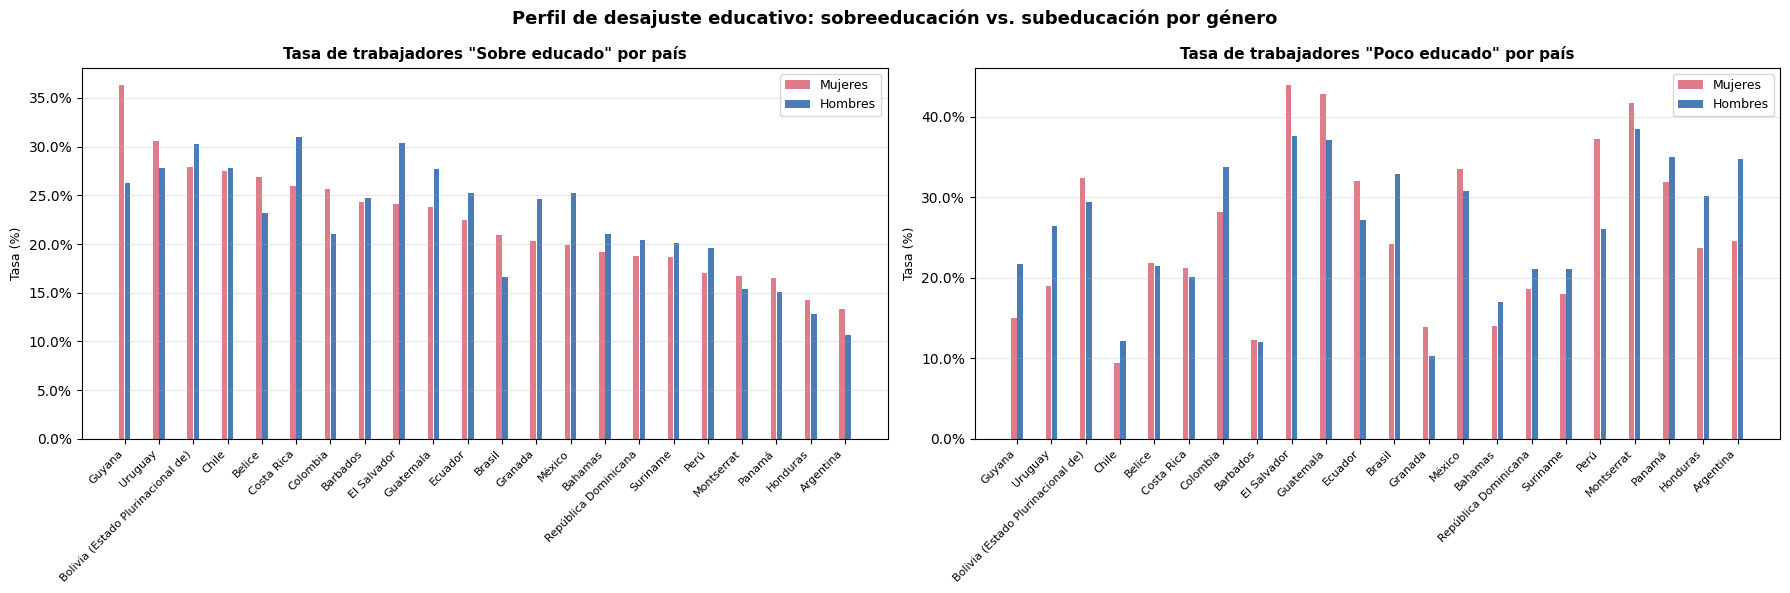

Promedio regional:
  tasa_sobre_mujeres: 22.3%
  tasa_sobre_hombres: 22.6%
  tasa_poco_mujeres: 25.4%
  tasa_poco_hombres: 26.2%


In [16]:
# Country-level full mismatch profile
cr_full = country_rates.sort_values('tasa_sobre_mujeres', ascending=False)
countries_ordered = cr_full['Área de referencia'].tolist()
x = np.arange(len(countries_ordered))
w = 0.18

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

labels_map = {'Sobre educado': ('tasa_sobre_mujeres', 'tasa_sobre_hombres'),
              'Poco educado':  ('tasa_poco_mujeres',  'tasa_poco_hombres')}

for ax, (desajuste, (col_f, col_m)) in zip(axes, labels_map.items()):
    vals_f = cr_full.set_index('Área de referencia').loc[countries_ordered, col_f]
    vals_m = cr_full.set_index('Área de referencia').loc[countries_ordered, col_m]

    ax.bar(x - w/2, vals_f, w*0.9, color=COLOR_F, label='Mujeres')
    ax.bar(x + w/2, vals_m, w*0.9, color=COLOR_M, label='Hombres')
    ax.set_xticks(x)
    ax.set_xticklabels(countries_ordered, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Tasa (%)', fontsize=9)
    ax.set_title(f'Tasa de trabajadores "{desajuste}" por país', fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Perfil de desajuste educativo: sobreeducación vs. subeducación por género',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mismatch_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("Promedio regional:")
for col in ['tasa_sobre_mujeres', 'tasa_sobre_hombres', 'tasa_poco_mujeres', 'tasa_poco_hombres']:
    print(f"  {col}: {cr_full[col].mean():.1f}%")